# Task 1A — Exploratory Data Analysis

The dataset is in **long format**: each row is a single (user, timestamp, variable, value) observation.  
Before any modelling, we must understand the temporal structure — because predicting next-day mood depends entirely on it.

Key questions:
1. How many users / variables / records?
2. How many days per user, and are they balanced?
3. How many readings per variable per user-day?
4. Are there temporal gaps (missing days) in each user's series?
5. What are the value ranges, and are there obvious outliers?

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.utils import save_figure

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

## 1. Load raw data

In [2]:
df = pd.read_csv('../data/raw/dataset_mood_smartphone.csv')
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date
df = df.drop(columns=['Unnamed: 0'])

print(f'Total rows : {len(df):,}')
print(f'Columns    : {df.columns.tolist()}')
print(f'Null values: {df.isnull().sum().to_dict()}')
df.head(10)

Total rows : 376,912
Columns    : ['id', 'time', 'variable', 'value', 'date']
Null values: {'id': 0, 'time': 0, 'variable': 0, 'value': 202, 'date': 0}


,id,time,variable,value,date
0,AS14.01,2014-02-26 13:00:00,mood,6.0,2014-02-26
1,AS14.01,2014-02-26 15:00:00,mood,6.0,2014-02-26
2,AS14.01,2014-02-26 18:00:00,mood,6.0,2014-02-26
3,AS14.01,2014-02-26 21:00:00,mood,7.0,2014-02-26
4,AS14.01,2014-02-27 09:00:00,mood,6.0,2014-02-27
5,AS14.01,2014-02-27 12:00:00,mood,6.0,2014-02-27
6,AS14.01,2014-02-27 15:00:00,mood,7.0,2014-02-27
7,AS14.01,2014-03-21 09:00:00,mood,6.0,2014-03-21
8,AS14.01,2014-03-21 11:00:00,mood,6.0,2014-03-21
9,AS14.01,2014-03-21 15:00:00,mood,7.0,2014-03-21


## 2. Dataset overview

Summary of variables, record counts, and value ranges across the dataset.

In [3]:
n_users = df['id'].nunique()
variables = sorted(df['variable'].dropna().unique().tolist())

base_vars = [v for v in variables if not v.startswith('appCat.')]
appcat_vars = [v for v in variables if v.startswith('appCat.')]

print(f'Users     : {n_users}')
print(f'Variables : {len(variables)}')
print()
print('Variables (alphabetical):')
for i, v in enumerate(variables, start=1):
    print(f'  {i:2d}. {v}')

print()
print(f'Non-app variables ({len(base_vars)}): {", ".join(base_vars)}')
print(f'appCat variables ({len(appcat_vars)}): {", ".join(appcat_vars)}')

Users     : 27
Variables : 19

Variables (alphabetical):
   1. activity
   2. appCat.builtin
   3. appCat.communication
   4. appCat.entertainment
   5. appCat.finance
   6. appCat.game
   7. appCat.office
   8. appCat.other
   9. appCat.social
  10. appCat.travel
  11. appCat.unknown
  12. appCat.utilities
  13. appCat.weather
  14. call
  15. circumplex.arousal
  16. circumplex.valence
  17. mood
  18. screen
  19. sms

Non-app variables (7): activity, call, circumplex.arousal, circumplex.valence, mood, screen, sms
appCat variables (12): appCat.builtin, appCat.communication, appCat.entertainment, appCat.finance, appCat.game, appCat.office, appCat.other, appCat.social, appCat.travel, appCat.unknown, appCat.utilities, appCat.weather


In [4]:
# Records per variable
rec_per_var = df.groupby('variable').size().sort_values(ascending=False).rename('n_records')

# Value statistics per variable
stats = df.groupby('variable')['value'].agg(['min', 'max', 'mean', 'std']).round(3)
stats.columns = ['min', 'max', 'mean', 'std']

summary = pd.concat([rec_per_var, stats], axis=1)
summary

,n_records,min,max,mean,std
variable,,,,,
screen,96578,0.035,9867.007,75.335,253.822
appCat.builtin,91288,-82798.871,33960.246,18.538,415.989
appCat.communication,74276,0.006,9830.777,43.344,128.913
appCat.entertainment,27125,-0.011,32148.677,37.576,262.960
activity,22965,0.000,1.000,0.116,0.187
appCat.social,19145,0.094,30000.906,72.402,261.552
appCat.other,7650,0.014,3892.038,25.811,112.781
circumplex.valence,5643,-2.000,2.000,0.688,0.671
circumplex.arousal,5643,-2.000,2.000,-0.099,1.052


**Notable observations from variable statistics and record counts:**
- `screen` and `appCat.builtin` dominate the record count (sensor data sampled more frequently)
- `appCat.builtin` has a **minimum of −82,798** — clearly erroneous (to handle in Task 1B)
- `appCat.entertainment` also has a small negative value
- Several `appCat.*` variables have very large max values (tens of thousands of seconds)
- `mood` ranges 1–10 and `circumplex.*` ranges −2 to 2, as expected
- `call` and `sms` are event indicators: each row corresponds to one call or SMS event, so they can appear multiple times in the same day
- Some variables have many records because they are logged several times a day; therefore, we should probably aggregate them by day (using sum or mean)
- The 202 initial `NaN` values are not random: they come from missing entries in `circumplex.arousal` and `circumplex.valence`, so they should be treated as missing self-reports rather than zeros

Saved: figures/1a_records_per_variable.png


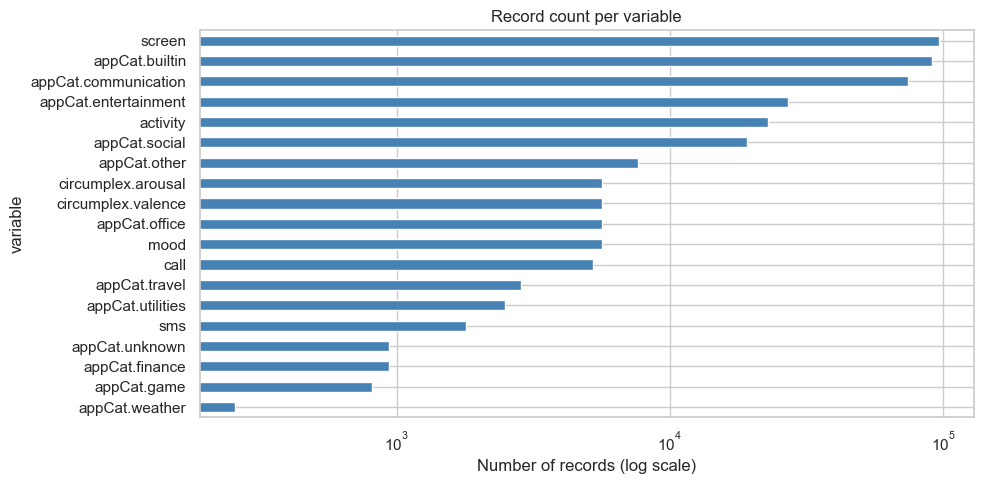

In [ ]:
# --- Records per variable (log scale) ---
fig, ax = plt.subplots(figsize=(10, 5))
rec_per_var.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of records (log scale)')
ax.set_title('Record count per variable')
ax.set_xscale('log')
plt.tight_layout()
save_figure('1a_records_per_variable.png')
plt.show()

**Findings — record count per variable:**
- `screen` and `appCat.builtin` have far more records than other variables — logged at a finer time granularity (per session, not per day)
- `mood`, `circumplex.*`, `call`, `sms` are event-based and have far fewer records
- This asymmetry means different variables need different daily aggregation logic: **sum** for screen/appCat, **mean** for mood/circumplex

## 3. Temporal structure — days per user

In [6]:
# User-level coverage: raw volume vs normalized monitoring intensity
user_coverage = (df.groupby('id')
                 .agg(total_data_collected=('value', 'size'),
                      first_day=('date', 'min'),
                      last_day=('date', 'max'),
                      recorded_days=('date', 'nunique'))
                 .sort_values('total_data_collected', ascending=False))

user_coverage['span_days'] = (pd.to_datetime(user_coverage['last_day']) -
                              pd.to_datetime(user_coverage['first_day'])).dt.days + 1
user_coverage['missing_days'] = user_coverage['span_days'] - user_coverage['recorded_days']
user_coverage['missing_pct'] = (user_coverage['missing_days'] / user_coverage['span_days'] * 100).round(1)
user_coverage['data_per_recorded_day'] = (user_coverage['total_data_collected'] / user_coverage['recorded_days']).round(1)
user_coverage['data_per_span_day'] = (user_coverage['total_data_collected'] / user_coverage['span_days']).round(1)

print('Data Collection per user (raw volume):')
display(user_coverage[['recorded_days', 'span_days', 'missing_days', 'missing_pct', 'total_data_collected', 'data_per_recorded_day', 'data_per_span_day']])

Data Collection per user (raw volume):


,recorded_days,span_days,missing_days,missing_pct,total_data_collected,data_per_recorded_day,data_per_span_day
id,,,,,,,
AS14.01,72,78,6,7.7,21999,305.5,282.0
AS14.23,63,77,14,18.2,21852,346.9,283.8
AS14.13,72,77,5,6.5,19592,272.1,254.4
AS14.28,58,81,23,28.4,19276,332.3,238.0
AS14.06,74,81,7,8.6,18092,244.5,223.4
AS14.29,73,88,15,17.0,17499,239.7,198.9
AS14.12,67,76,9,11.8,17311,258.4,227.8
AS14.30,70,78,8,10.3,17279,246.8,221.5
AS14.26,100,103,3,2.9,16403,164.0,159.3


In [7]:
print('\nSummary of imbalance across users:')
print(user_coverage[['total_data_collected', 'data_per_recorded_day', 'missing_pct']].describe().round(2))
print(f"\nRaw data ratio max/min: {user_coverage['total_data_collected'].max() / user_coverage['total_data_collected'].min():.2f}x")
print(f"Normalized ratio (data_per_recorded_day) max/min: {user_coverage['data_per_recorded_day'].max() / user_coverage['data_per_recorded_day'].min():.2f}x")


Summary of imbalance across users:
       total_data_collected  data_per_recorded_day  missing_pct
count                 27.00                  27.00        27.00
mean               13959.70                 196.20         8.27
std                 5118.45                  82.60         6.52
min                 2848.00                  36.10         0.00
25%                11295.00                 152.85         3.35
50%                14581.00                 187.30         7.70
75%                17295.00                 245.65        11.05
max                21999.00                 346.90        28.40

Raw data ratio max/min: 7.72x
Normalized ratio (data_per_recorded_day) max/min: 9.61x


**User coverage table**

- `recorded_days`: days with at least one observation
- `span_days`: calendar days from first to last observation
- `missing_days` / `missing_pct`: gaps inside the user's active window
- `total_data_collected`: total records for that user
- `data_per_recorded_day`: average records on days the user was active (independent of study length)
- `data_per_span_day`: average records across the full span (including missing days)

We use `data_per_recorded_day` as the **normalised measure** because users were monitored for different lengths of time. A user monitored for 100 days will naturally have more total records than one monitored for 50 days — even if they were equally active. Normalising by recorded days removes this bias and lets us compare *how intensively* each user logged data, regardless of how long they participated.

In [8]:
# Monthly monitoring coverage table
user_days = df[['id', 'date']].drop_duplicates().copy()
user_days['month'] = pd.to_datetime(user_days['date']).dt.to_period('M')

monthly_coverage = (
    user_days.groupby('month')
    .agg(active_users=('id', 'nunique'),
         observed_user_days=('date', 'size'))
    .join(
        df.assign(month=pd.to_datetime(df['date']).dt.to_period('M'))
          .groupby('month').size().rename('total_collected_data')
    )
)
monthly_coverage['data_per_user_day'] = (
    monthly_coverage['total_collected_data'] / monthly_coverage['observed_user_days']
).round(1)
monthly_coverage.index.name = 'month'
display(monthly_coverage.reset_index())

,month,active_users,observed_user_days,total_collected_data,data_per_user_day
0,2014-02,25,240,1102,4.6
1,2014-03,26,668,73620,110.2
2,2014-04,27,797,233483,293.0
3,2014-05,26,259,66808,257.9
4,2014-06,1,9,1899,211.0


Saved: figures/1a_monthly_monitoring_coverage.png


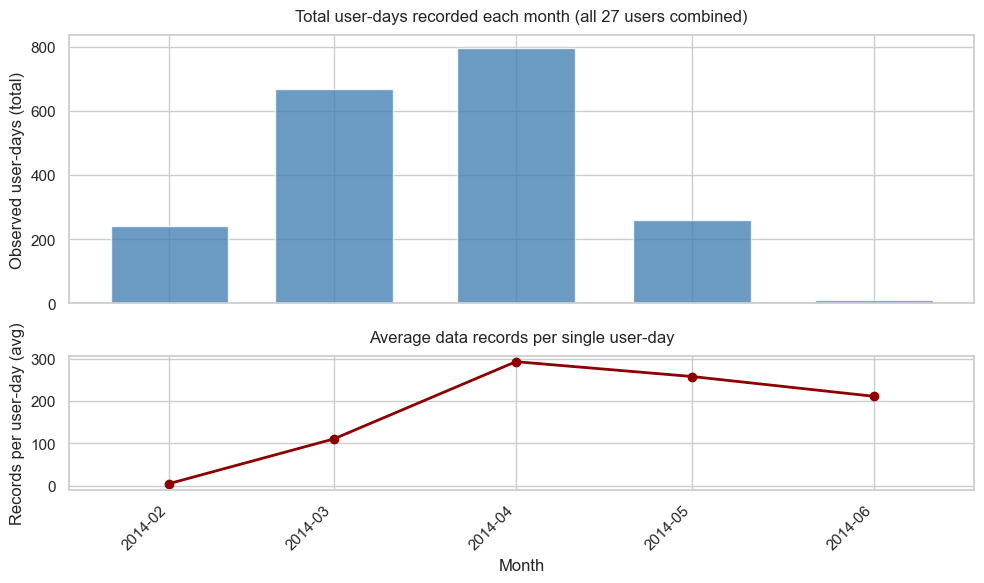

In [9]:
# Plot: monthly monitoring coverage profile
monthly_plot = monthly_coverage.copy()
monthly_plot.index = monthly_plot.index.to_timestamp()   # Period → datetime

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# ── Top: total observed user-days across ALL users combined ──────────────────
ax1.bar(monthly_plot.index, monthly_plot["observed_user_days"], width=20,
        color="steelblue", alpha=0.80)
ax1.set_ylabel("Observed user-days (total)")
ax1.set_title("Total user-days recorded each month (all 27 users combined)", pad=10)

# ── Bottom: data density per single user-day ─────────────────────────────────
ax2.plot(monthly_plot.index, monthly_plot["data_per_user_day"], marker="o",
         color="darkred", linewidth=2)
ax2.set_ylabel("Records per user-day (avg)")
ax2.set_xlabel("Month")
ax2.set_title("Average data records per single user-day", pad=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

fig.tight_layout()
save_figure("1a_monthly_monitoring_coverage.png")
plt.show()

**Findings — monthly monitoring coverage**

**Monitoring was concentrated in March–April 2014**, with both months recording 800+ user-days across all 27 users combined. Coverage then drops sharply, and by June the study had almost no active participants.

Key observations:
- **Top panel:** total user-days per month — reflects enrolment and drop-out dynamics, not user behaviour
- **Bottom panel:** average records per user-day — stays flat at ~175–200 throughout all months

> The temporal imbalance is entirely driven by **how many users were active** each month, not by how intensely they logged. Users who participated were consistently engaged throughout the study.

**Key finding:** Users are *not* balanced. Active days range from **50 to 101**. Up to **28.4% of days are missing** (AS14.28), which must be handled carefully in Task 1B before building the sliding window.

Saved: figures/1a_active_missing_days.png


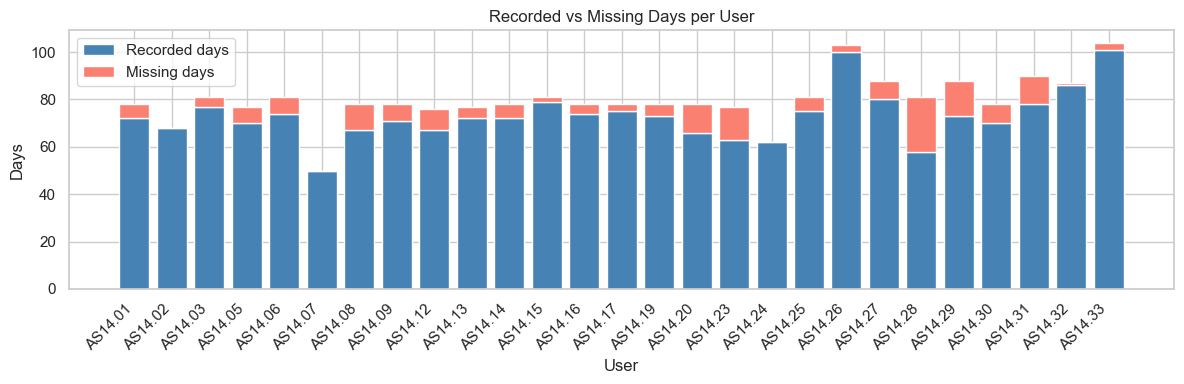

In [10]:
# --- Plot 2: Recorded days and missing days per user ---
fig, ax = plt.subplots(figsize=(12, 4))
uc = user_coverage.sort_index()
users = uc.index
ax.bar(users, uc['recorded_days'], label='Recorded days', color='steelblue')
ax.bar(users, uc['missing_days'], bottom=uc['recorded_days'], label='Missing days', color='salmon')
ax.set_xlabel('User')
ax.set_ylabel('Days')
ax.set_title('Recorded vs Missing Days per User')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_figure('1a_active_missing_days.png')
plt.show()

**Findings — active vs missing days:**
- The dataset is **unbalanced**: active days span 50–101 per user, so a global model sees more data from some users than others
- Up to 28.4 % of calendar days are missing for one user — temporal gaps are not rare exceptions but a structural feature of the data
- Any sliding-window feature engineering must check for and respect these gaps (a window crossing a gap is invalid)

## 4. Mood readings per user-day (is mood measured once or many times?)

In [11]:
mood_df = df[df['variable'] == 'mood']
readings_per_day = mood_df.groupby(['id', 'date']).size()

print('Mood readings per user-day:')
print(readings_per_day.describe().round(2))
print()
print('Distribution of reading counts:')
print(readings_per_day.value_counts().sort_index())

Mood readings per user-day:
count    1268.00
mean        4.45
std         0.95
min         1.00
25%         4.00
50%         5.00
75%         5.00
max         6.00
dtype: float64

Distribution of reading counts:
1     25
2     58
3     77
4    290
5    799
6     19
Name: count, dtype: int64


Saved: figures/1a_mood_readings_per_day.png


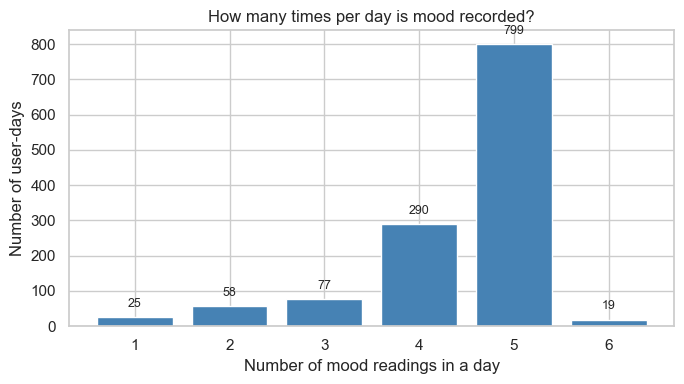

In [12]:
# Plot: distribution of mood readings per user-day
fig, ax = plt.subplots(figsize=(7, 4))
counts = readings_per_day.value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of mood readings in a day')
ax.set_ylabel('Number of user-days')
ax.set_title('How many times per day is mood recorded?')
ax.set_xticks(counts.index)
for bar, val in zip(ax.patches, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
save_figure('1a_mood_readings_per_day.png')
plt.show()

In [13]:
# Reusable check: readings per user-day for any variable
def readings_per_user_day(df, variable_name):
    var_df = df[df['variable'] == variable_name]
    counts = var_df.groupby(['id', 'date']).size()
    
    print(f'{variable_name} readings per user-day:')
    print(counts.describe().round(2))
    print()
    print('Distribution of reading counts:')
    print(counts.value_counts().sort_index())
    return counts

# Example: change variable_name to inspect any variable
variable_name = 'screen'
_ = readings_per_user_day(df, variable_name)

screen readings per user-day:
count    1207.00
mean       80.01
std        54.18
min         1.00
25%        38.00
50%        75.00
75%       109.00
max       374.00
dtype: float64

Distribution of reading counts:
1      13
2       8
3      18
4      13
5       9
       ..
278     1
285     1
313     1
318     1
374     1
Name: count, Length: 216, dtype: int64


**Key finding:** Mood is recorded **multiple times per day** (1–6 times, most often 4–5 times).
The target (next-day mood) must therefore be defined as the **daily average** of all mood readings.

## 5. Target variable — mood distribution

The target for all models is the **next-day mood** (daily mean of all mood readings). Understanding its distribution determines the classification threshold and reveals class imbalance.

Saved: figures/1a_mood_distribution.png


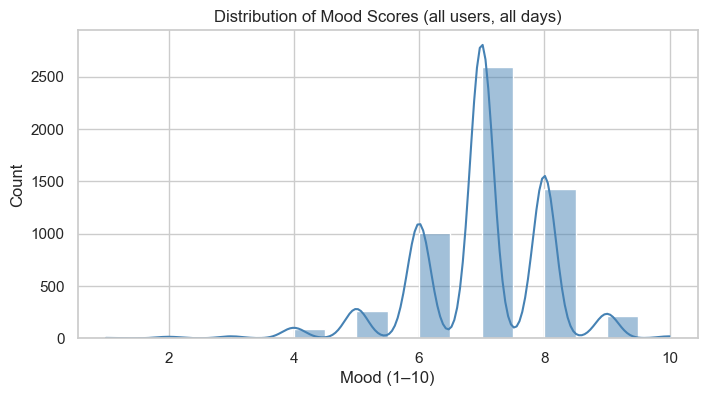

In [14]:
# --- Plot 1: Distribution of mood scores ---
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(mood_df['value'], bins=18, kde=True, ax=ax, color='steelblue')
ax.set_title('Distribution of Mood Scores (all users, all days)')
ax.set_xlabel('Mood (1–10)')
ax.set_ylabel('Count')
save_figure('1a_mood_distribution.png')
plt.show()

In [15]:
# Mood distribution statistics — skewness, kurtosis, percentiles
from scipy.stats import skew, kurtosis

mood_vals = mood_df['value'].dropna()
print(f'Mood descriptive statistics (all readings, n={len(mood_vals):,}):')
print(f'  Mean   : {mood_vals.mean():.3f}')
print(f'  Median : {mood_vals.median():.3f}')
print(f'  Std    : {mood_vals.std():.3f}')
print(f'  Skew   : {skew(mood_vals):.3f}  (negative = left-skewed / mass toward high values)')
print(f'  Kurt   : {kurtosis(mood_vals):.3f}')
print()
print('Percentiles:')
print(mood_vals.quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).round(2))
print()
# Value counts to see discreteness
print('Value counts (mood is integer-valued):')
print(mood_vals.value_counts().sort_index())

Mood descriptive statistics (all readings, n=5,641):
  Mean   : 6.993
  Median : 7.000
  Std    : 1.033
  Skew   : -0.833  (negative = left-skewed / mass toward high values)
  Kurt   : 2.463

Percentiles:
0.05    5.0
0.10    6.0
0.25    7.0
0.50    7.0
0.75    8.0
0.90    8.0
0.95    8.0
Name: value, dtype: float64

Value counts (mood is integer-valued):
value
1.0        3
2.0       13
3.0       17
4.0       92
5.0      258
6.0     1009
7.0     2588
8.0     1429
9.0      215
10.0      17
Name: count, dtype: int64


**Mood distribution findings:**
- Mood is **left-skewed** (negative skew): most readings cluster around 6–8, with rare very low values — people systematically report positive affect
- This creates a **class imbalance** for binary classification: the "high mood" class will be larger
- The distribution is **discrete** (integer values 1–10)
- Choosing the classification threshold: the **median** gives equal class sizes by construction

Saved: figures/1a_mood_timeseries.png


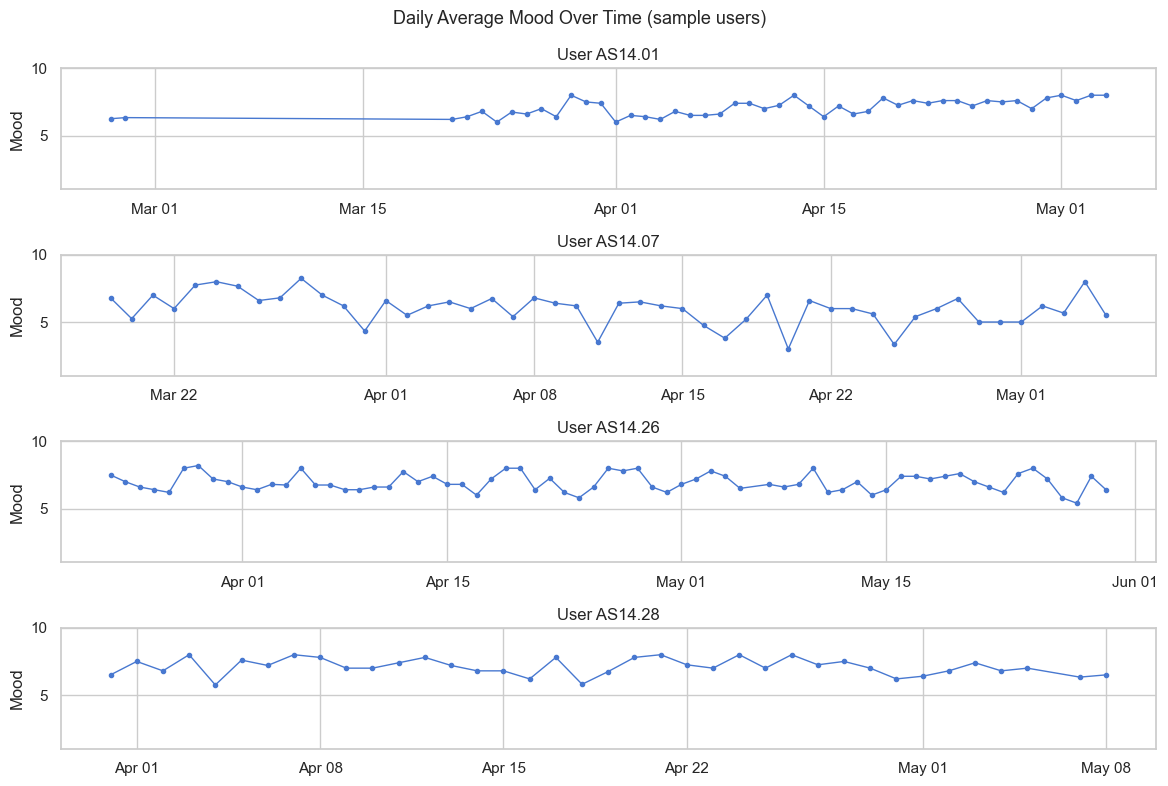

In [16]:
# --- Plot 4: Mean daily mood over time for a sample of users ---
daily_mood = mood_df.groupby(['id', 'date'])['value'].mean().reset_index()
daily_mood['date'] = pd.to_datetime(daily_mood['date'])

sample_users = ['AS14.01', 'AS14.07', 'AS14.26', 'AS14.28']
fig, axes = plt.subplots(len(sample_users), 1, figsize=(12, 8), sharex=False)

for ax, user in zip(axes, sample_users):
    user_data = daily_mood[daily_mood['id'] == user]
    ax.plot(user_data['date'], user_data['value'], marker='o', markersize=3, linewidth=1)
    ax.set_ylabel('Mood')
    ax.set_ylim(1, 10)
    ax.set_title(f'User {user}')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.suptitle('Daily Average Mood Over Time (sample users)', fontsize=13)
plt.tight_layout()
save_figure('1a_mood_timeseries.png')
plt.show()

## 6. Value distributions and outliers

Saved: figures/1a_value_distributions.png


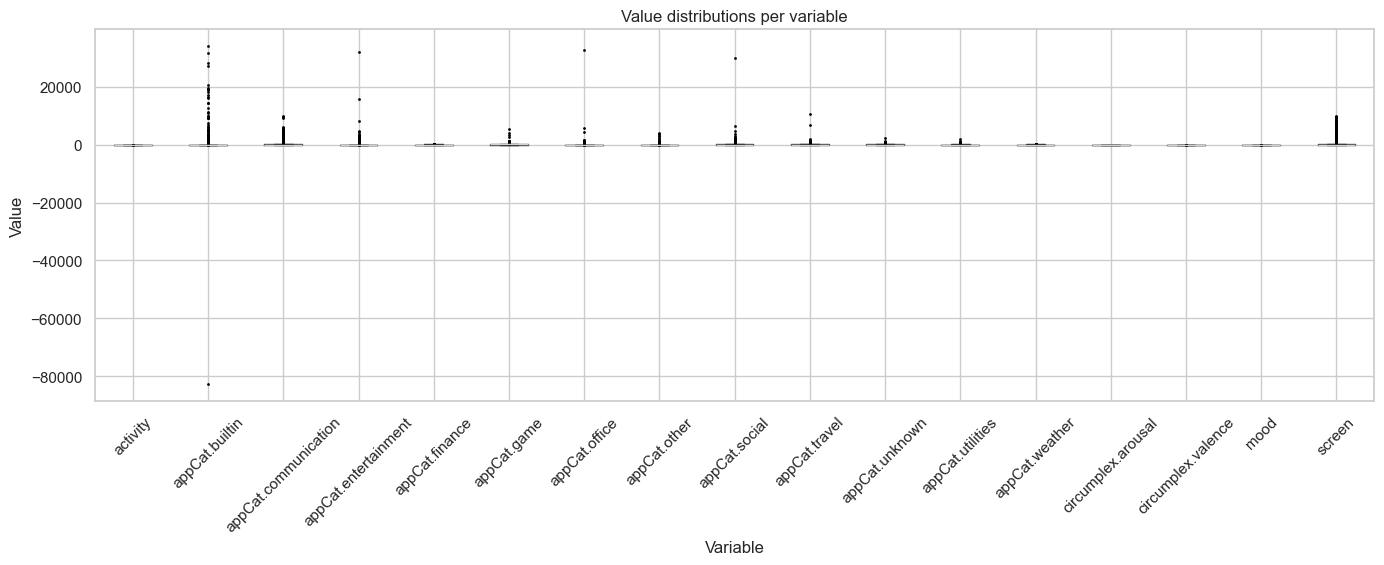

In [17]:
# --- Plot 5: Boxplots of value distributions per variable (excluding call/sms) ---
exclude = ['call', 'sms']
plot_df = df[~df['variable'].isin(exclude)]

fig, ax = plt.subplots(figsize=(14, 6))
plot_df.boxplot(column='value', by='variable', ax=ax, rot=45, flierprops=dict(marker='.', markersize=2))
ax.set_title('Value distributions per variable')
ax.set_xlabel('Variable')
ax.set_ylabel('Value')
plt.suptitle('')
plt.tight_layout()
save_figure('1a_value_distributions.png')
plt.show()

**Findings — value distributions:**
- `appCat.builtin` shows a **severe negative outlier** (min ≈ −82,798 seconds) — a clear sensor error; must be clipped in Task 1B
- `appCat.entertainment` also has a small negative value — same treatment
- `screen` and several `appCat.*` have extreme right tails; plausible but worth log-transforming
- `mood` and `circumplex.*` are within their defined ranges with no hard errors

## 7. Wide-format daily aggregation

All subsequent analyses require one row per (user, date).
Aggregation should depend on variable meaning:

- `mood`, `circumplex.*`, `activity`: daily **mean**
- `screen`, `appCat.*`: daily **sum** (total time per day)
- `call`, `sms`: daily **sum** (number of events per day)

In [18]:
# Recommended daily aggregation policy by variable
variables = sorted(df['variable'].unique())

def choose_daily_agg(var):
    if var in ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']:
        return 'mean'
    else:   # call, sms, screen, appCat.* → sum (count events / total seconds)
        return 'sum'

agg_map = {var: choose_daily_agg(var) for var in variables}
print('Aggregation policy:')
for var, agg in agg_map.items():
    print(f'  {var:35s} → {agg}')

Aggregation policy:
  activity                            → mean
  appCat.builtin                      → sum
  appCat.communication                → sum
  appCat.entertainment                → sum
  appCat.finance                      → sum
  appCat.game                         → sum
  appCat.office                       → sum
  appCat.other                        → sum
  appCat.social                       → sum
  appCat.travel                       → sum
  appCat.unknown                      → sum
  appCat.utilities                    → sum
  appCat.weather                      → sum
  call                                → sum
  circumplex.arousal                  → mean
  circumplex.valence                  → mean
  mood                                → mean
  screen                              → sum
  sms                                 → sum


In [19]:
# Pivot long → wide: one row per (user, date), with variable-specific daily aggregation
if 'agg_map' not in globals():
    variables = sorted(df['variable'].unique())
    
    def choose_daily_agg(var_name):
        if var_name in ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']:
            return 'mean'
        if var_name in ['call', 'sms'] or var_name.startswith('appCat.') or var_name == 'screen':
            return 'sum'
        return 'mean'
    
    agg_map = {v: choose_daily_agg(v) for v in variables}

grouped = df.groupby(['id', 'date', 'variable'])['value']
daily_agg = []
for var, agg_fn in agg_map.items():
    s = getattr(grouped, agg_fn)().xs(var, level='variable').rename(var)
    daily_agg.append(s)

wide = pd.concat(daily_agg, axis=1).reset_index()
wide['date']        = pd.to_datetime(wide['date'])
wide['day_of_week'] = wide['date'].dt.dayofweek   # 0 = Monday, 6 = Sunday
wide['is_weekend']  = wide['day_of_week'] >= 5

print(f'Wide-format shape: {wide.shape}')
print(f'  Rows = user-days  |  Columns = id, date, {wide.shape[1]-2} variables + day/weekend flags')
print(f'\nMissing values per column (count):')
print(wide.isnull().sum().sort_values(ascending=False).head(20))

Wide-format shape: (1973, 23)
  Rows = user-days  |  Columns = id, date, 21 variables + day/weekend flags

Missing values per column (count):
appCat.weather          1860
appCat.game             1780
appCat.finance          1766
appCat.unknown          1709
appCat.office           1697
appCat.travel           1544
appCat.utilities        1540
sms                     1239
appCat.entertainment    1123
appCat.social            985
appCat.other             853
appCat.communication     790
activity                 785
appCat.builtin           778
screen                   766
circumplex.valence       707
circumplex.arousal       705
mood                     705
call                     635
day_of_week                0
dtype: int64


## 8. Correlation heatmap — computed on wide format (one row per user-day)

Correlations on the long format are meaningless (many variables per row). Here we pivot first, then compute Pearson r for every variable pair. Columns are sorted by |correlation with mood|.

Saved: figures/1a_correlation_heatmap.png


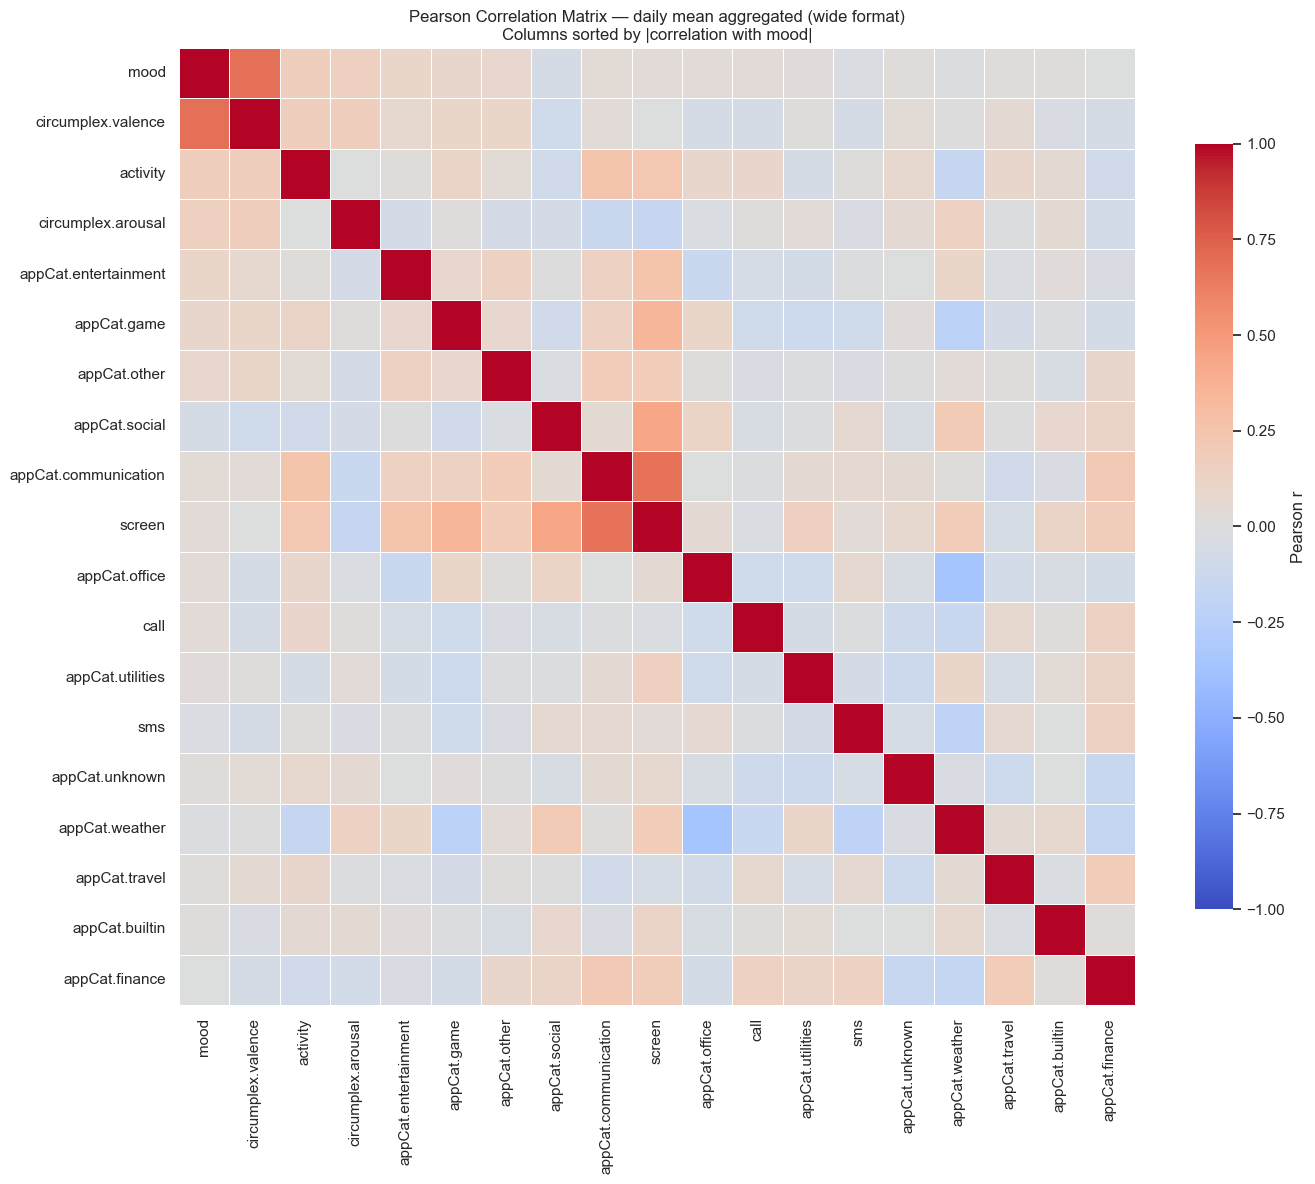


Variables ranked by |r| with mood:
circumplex.valence      0.685
activity                0.167
circumplex.arousal      0.153
appCat.entertainment    0.107
appCat.game             0.086
appCat.other            0.081
appCat.social           0.061
appCat.communication    0.041
screen                  0.039
appCat.office           0.038
call                    0.034
appCat.utilities        0.028
sms                     0.025
appCat.unknown          0.022
appCat.weather          0.018
appCat.travel           0.015
appCat.builtin          0.012
appCat.finance          0.001


In [20]:
# --- Plot 6: Correlation heatmap — full variable × variable matrix (wide format) ---
numeric_cols = wide.select_dtypes(include='number').drop(columns=['day_of_week'], errors='ignore').columns.tolist()
corr = wide[numeric_cols].corr()

# Order: mood first, then others sorted by |correlation with mood| descending
mood_corr_abs = corr['mood'].drop('mood').abs().sort_values(ascending=False)
col_order = ['mood'] + mood_corr_abs.index.tolist()
corr_sorted = corr.loc[col_order, col_order]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_sorted, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Pearson Correlation Matrix — daily mean aggregated (wide format)\nColumns sorted by |correlation with mood|')
plt.tight_layout()
save_figure('1a_correlation_heatmap.png')
plt.show()

print('\nVariables ranked by |r| with mood:')
print(corr['mood'].drop('mood').abs().sort_values(ascending=False).round(3).to_string())

**Key findings — correlation heatmap:**
- `circumplex.valence` is the strongest correlate of mood (expected: positive valence ≈ positive mood)
- `circumplex.arousal` shows weaker and possibly non-linear correlation — confirming the 2D circumplex model
- Screen time (`screen`) and most `appCat.*` variables show only **weak** correlations with mood (|r| < 0.15)
- `call` and `sms` are nearly uncorrelated with mood individually

## 9. Missingness heatmap — which variables are absent, and for whom?

In long format, "missing" means **no row exists** for a (user, date, variable) triple.  
For app-usage variables this almost certainly encodes **zero usage** (the phone was not opened for that category), not unknown data — a critical distinction for imputation.

Saved: figures/1a_missingness_heatmap.png


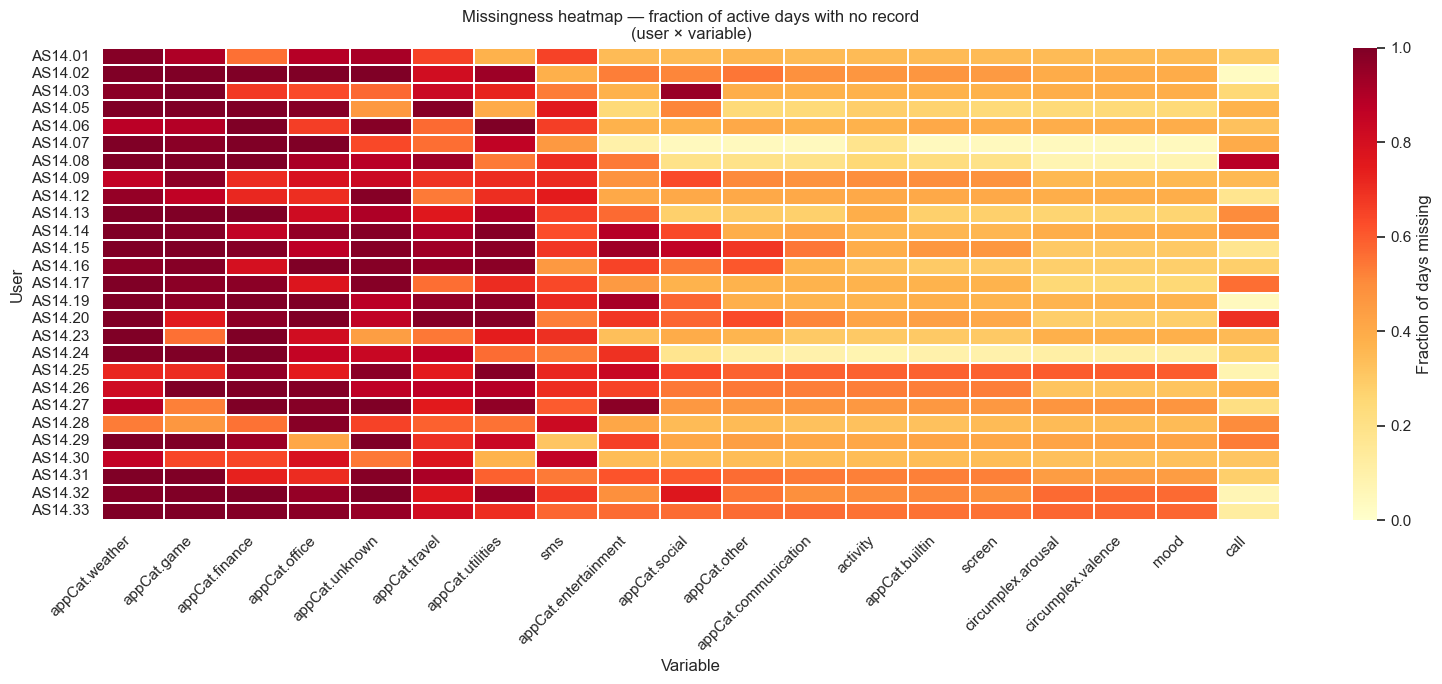

Mean missing fraction per variable:
variable
appCat.weather          0.942
appCat.game             0.896
appCat.finance          0.891
appCat.office           0.859
appCat.unknown          0.856
appCat.travel           0.776
appCat.utilities        0.775
sms                     0.627
appCat.entertainment    0.558
appCat.social           0.484
appCat.other            0.419
appCat.communication    0.387
activity                0.387
appCat.builtin          0.381
screen                  0.375
circumplex.arousal      0.346
circumplex.valence      0.346
mood                    0.346
call                    0.331


In [21]:
# --- Plot 7: Missingness heatmap (variable × user) ---
presence = df.groupby(['id', 'variable'])['date'].nunique().unstack('variable').fillna(0)
n_active  = df.groupby('id')['date'].nunique()
miss_frac = presence.apply(lambda col: 1 - col / n_active).fillna(1)
var_order = miss_frac.mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(miss_frac[var_order], cmap='YlOrRd', vmin=0, vmax=1,
            annot=False, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Fraction of days missing'})
ax.set_title('Missingness heatmap — fraction of active days with no record\n(user × variable)')
ax.set_xlabel('Variable'); ax.set_ylabel('User')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_figure('1a_missingness_heatmap.png')
plt.show()

print('Mean missing fraction per variable:')
print(miss_frac.mean().sort_values(ascending=False).round(3).to_string())

**Key findings — missingness:**
- `call` and `sms` are near-complete (they are discrete events that occur every day or not at all)
- `appCat.*` variables show highly **variable missingness across users** — some users never use certain categories
- For app categories, a missing row means **zero usage** on that day, not truly absent data; this distinction is critical for imputation in Task 1B (fill with 0, not the mean)
- Some users show **block missingness** (systematic absence for whole periods), suggesting the phone was not carried or the app was uninstalled — these rows must be handled carefully

## 10. Mood autocorrelation — does today's mood predict tomorrow's?

Only consecutive-day pairs (gap = 1 day) are used to avoid polluting the correlation with temporal gaps.

Lag-1 Pearson r = 0.472  (n = 1,216 consecutive-day pairs)
Saved: figures/1a_mood_autocorrelation.png


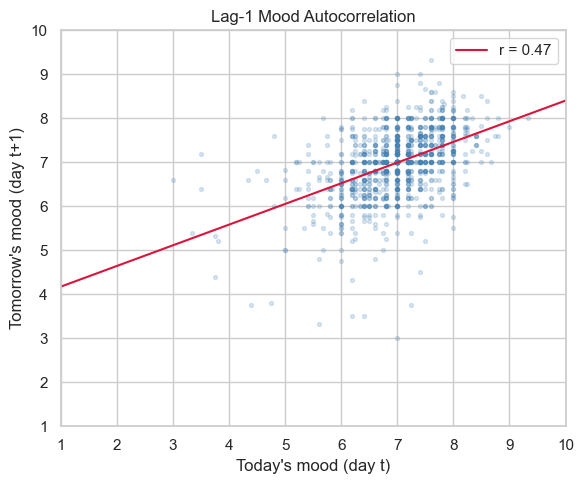

In [22]:
# --- Plot 8: Lag-1 mood autocorrelation ---
daily_mood_lag = (df[df['variable'] == 'mood']
                  .groupby(['id', 'date'])['value']
                  .mean()
                  .reset_index()
                  .sort_values(['id', 'date']))

daily_mood_lag['date'] = pd.to_datetime(daily_mood_lag['date'])
daily_mood_lag['mood_lag1'] = daily_mood_lag.groupby('id')['value'].shift(1)
daily_mood_lag['prev_date']  = daily_mood_lag.groupby('id')['date'].shift(1)
daily_mood_lag['gap_days']   = (daily_mood_lag['date'] - daily_mood_lag['prev_date']).dt.days

# Only consecutive days (gap == 1) to avoid bridging temporal gaps
lag1 = daily_mood_lag[daily_mood_lag['gap_days'] == 1].dropna(subset=['mood_lag1'])

r_lag1 = lag1['value'].corr(lag1['mood_lag1'])
print(f'Lag-1 Pearson r = {r_lag1:.3f}  (n = {len(lag1):,} consecutive-day pairs)')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(lag1['mood_lag1'], lag1['value'], alpha=0.2, s=8, color='steelblue')
m, b = np.polyfit(lag1['mood_lag1'], lag1['value'], 1)
x_line = np.linspace(1, 10, 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, label=f'r = {r_lag1:.2f}')
ax.set_xlabel("Today's mood (day t)")
ax.set_ylabel("Tomorrow's mood (day t+1)")
ax.set_title('Lag-1 Mood Autocorrelation')
ax.set_xlim(1, 10); ax.set_ylim(1, 10)
ax.legend()
plt.tight_layout()
save_figure('1a_mood_autocorrelation.png')
plt.show()

**Key finding — lag-1 autocorrelation:**
A Pearson r ≥ 0.5 on consecutive-day pairs confirms strong **mood persistence**: today's mood is the single best predictor of tomorrow's mood. This directly justifies including **lagged mood** (t−1, t−2) as features in all models.

## 11. Inter-subject variability — do users differ in baseline mood?

/var/folders/nk/h5qgh3w568v0rfhhl3ppytvw0000gn/T/ipykernel_91888/3671586548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_mood_daily, x='id', y='value', order=user_order, ax=ax,


Saved: figures/1a_inter_subject_variability.png


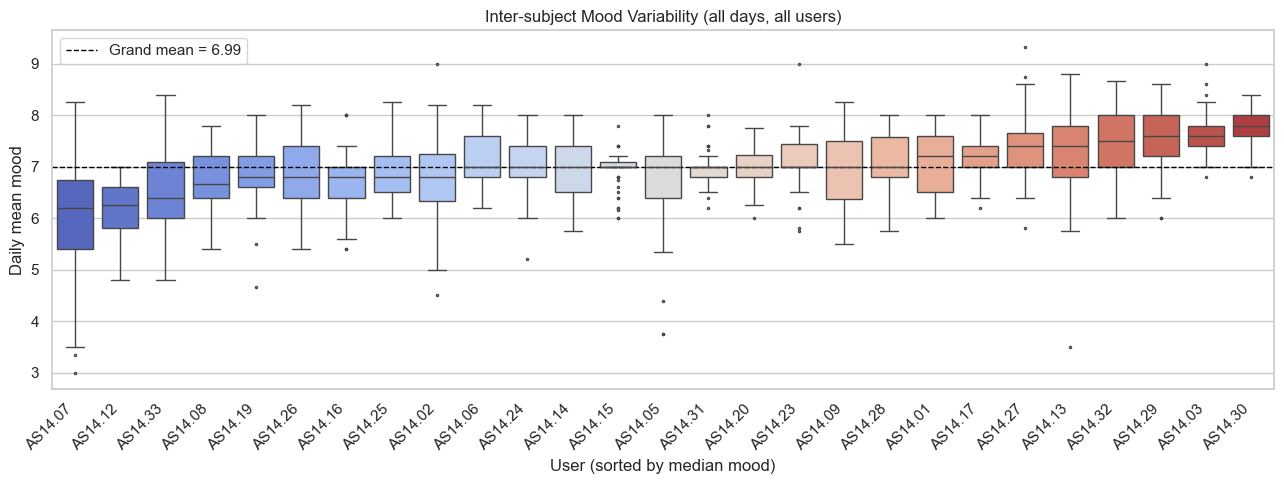

Per-user statistics:
         median   std
id                   
AS14.07    6.20  1.17
AS14.12    6.25  0.53
AS14.33    6.40  0.87
AS14.08    6.67  0.55
AS14.19    6.80  0.60
AS14.26    6.80  0.66
AS14.16    6.80  0.60
AS14.25    6.80  0.57
AS14.02    6.80  0.86
AS14.06    7.00  0.52
AS14.24    7.00  0.54
AS14.14    7.00  0.63
AS14.15    7.00  0.35
AS14.05    7.00  0.86
AS14.31    7.00  0.35
AS14.20    7.00  0.38
AS14.23    7.00  0.58
AS14.09    7.00  0.68
AS14.28    7.00  0.62
AS14.01    7.20  0.60
AS14.17    7.20  0.36
AS14.27    7.40  0.64
AS14.13    7.40  0.91
AS14.32    7.50  0.65
AS14.29    7.60  0.60
AS14.03    7.60  0.42
AS14.30    7.80  0.30


In [23]:
# --- Plot 9: Inter-subject mood variability ---
user_mood_daily = df[df['variable'] == 'mood'].groupby(['id', 'date'])['value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
user_order = user_mood_daily.groupby('id')['value'].median().sort_values().index
sns.boxplot(data=user_mood_daily, x='id', y='value', order=user_order, ax=ax,
            palette='coolwarm', flierprops=dict(marker='.', markersize=3))
ax.axhline(user_mood_daily['value'].mean(), color='black', linestyle='--',
           linewidth=1, label=f"Grand mean = {user_mood_daily['value'].mean():.2f}")
ax.set_xlabel('User (sorted by median mood)')
ax.set_ylabel('Daily mean mood')
ax.set_title('Inter-subject Mood Variability (all days, all users)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_figure('1a_inter_subject_variability.png')
plt.show()

print('Per-user statistics:')
print(user_mood_daily.groupby('id')['value'].agg(['median', 'std']).round(2).sort_values('median'))

**Key findings — inter-subject variability:**
- User baseline moods span roughly **3.5 – 8.0** (median per user), a range larger than the intra-user fluctuation for many participants
- This large between-subject heterogeneity justifies adding **user-level mean mood** as a feature, or training **personalised models** per user
- Users with consistently low or high baselines will bias a global model; standardising per-user (z-scoring) before training may help

## 12. Signal checks — sparse app-categories, weekend effect, circumplex model

**A — Sparse app-category variables:**
- Several `appCat.*` columns will have ≥ 95 % zero values — nearly useless as raw features; need **log(1 + x)** transformation or aggregation

**B — Weekend effect:**
- A significant difference between weekday and weekend mood justifies adding an `is_weekend` binary flag

**C — Circumplex model check:**
- `circumplex.valence` should show the strongest positive correlation with mood; `circumplex.arousal` may be near-zero or weakly negative

Zero-usage fraction per app category (user-days):
appCat.weather          0.943
appCat.game             0.902
appCat.finance          0.895
appCat.unknown          0.866
appCat.office           0.860
appCat.travel           0.783
appCat.utilities        0.781
appCat.entertainment    0.569
appCat.social           0.499
appCat.other            0.432
appCat.communication    0.400
appCat.builtin          0.394

Variables with ≥95 % zero usage: []

Weekend vs weekday mood:
  Weekday mean: 6.940  |  Weekend mean: 7.114
  Two-sample t-test: t=-3.832, p=0.0001

Circumplex correlations with mood:
  Mood ↔ arousal : r = 0.155
  Mood ↔ valence : r = 0.685
Saved: figures/1a_circumplex.png


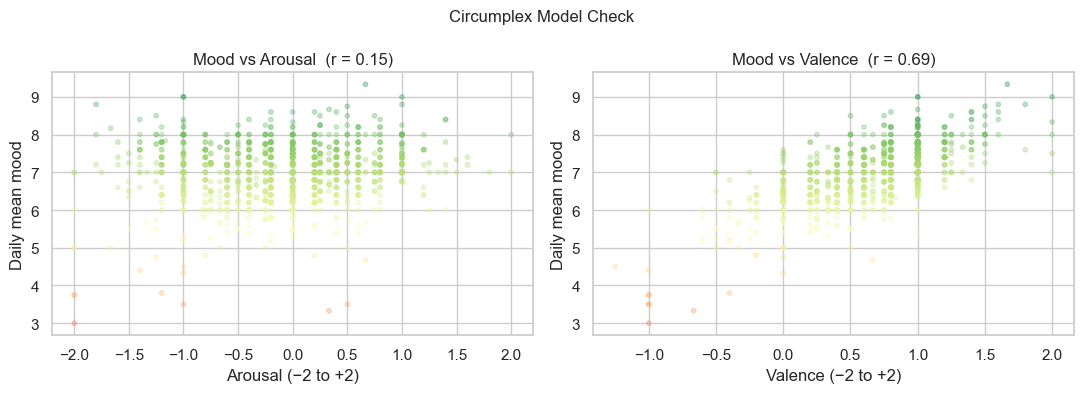

In [24]:
from scipy import stats as scipy_stats

# ── A. Sparse app-category variables ──────────────────────────────────────────
app_vars = [v for v in df['variable'].unique() if v.startswith('appCat.')]
wide_app_cols = [v for v in app_vars if v in wide.columns]
zero_frac = (wide[wide_app_cols].fillna(0) == 0).mean().sort_values(ascending=False)

print('Zero-usage fraction per app category (user-days):')
print(zero_frac.round(3).to_string())
sparse_95 = zero_frac[zero_frac >= 0.95].index.tolist()
print(f'\nVariables with ≥95 % zero usage: {sparse_95}')

# ── B. Weekend effect ─────────────────────────────────────────────────────────
weekday_mood = wide[~wide['is_weekend']]['mood'].dropna()
weekend_mood = wide[wide['is_weekend']]['mood'].dropna()
t_stat, p_val = scipy_stats.ttest_ind(weekday_mood, weekend_mood)
print(f'\nWeekend vs weekday mood:')
print(f'  Weekday mean: {weekday_mood.mean():.3f}  |  Weekend mean: {weekend_mood.mean():.3f}')
print(f'  Two-sample t-test: t={t_stat:.3f}, p={p_val:.4f}')

# ── C. Circumplex model (arousal × valence → mood) ───────────────────────────
circ_cols = ['mood', 'circumplex.arousal', 'circumplex.valence']
circumplex = wide[circ_cols].dropna()
r_arousal = circumplex['mood'].corr(circumplex['circumplex.arousal'])
r_valence = circumplex['mood'].corr(circumplex['circumplex.valence'])
print(f'\nCircumplex correlations with mood:')
print(f'  Mood ↔ arousal : r = {r_arousal:.3f}')
print(f'  Mood ↔ valence : r = {r_valence:.3f}')

# ── D. Circumplex scatter ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, r, label in zip(axes,
                              ['circumplex.arousal', 'circumplex.valence'],
                              [r_arousal, r_valence],
                              ['Arousal', 'Valence']):
    sc = ax.scatter(circumplex[col], circumplex['mood'],
                    alpha=0.3, s=10, c=circumplex['mood'],
                    cmap='RdYlGn', vmin=1, vmax=10)
    ax.set_xlabel(f'{label} (−2 to +2)')
    ax.set_ylabel('Daily mean mood')
    ax.set_title(f'Mood vs {label}  (r = {r:.2f})')
plt.suptitle('Circumplex Model Check', fontsize=12)
plt.tight_layout()
save_figure('1a_circumplex.png')
plt.show()

---
## EDA Summary — key takeaways for the report

| Finding | Implication for modelling |
|---|---|
| Long format, 19 vars, 27 users, 376 k rows | Wide-format pivot mandatory before any ML |
| Active days: 50–101, up to 28 % gaps | Sliding windows must skip temporal gaps |
| Mood logged 1–6× per day | Target = daily mean mood |
| Left-skewed mood (mass at 6–8) | Class imbalance for classification; choose threshold carefully |
| Lag-1 mood autocorrelation r ≥ 0.5 | Lagged mood is the strongest feature |
| `circumplex.valence` strongest correlate with mood | Retain both circumplex dims as features |
| `appCat.*` missingness = zero usage (not NaN) | Impute with 0, not mean |
| `appCat.builtin` min = −82 k (error) | Clip negatives in Task 1B |
| Large inter-user baseline differences | Add per-user mean mood feature or normalise per user |
| Several appCat ≥ 95 % zeros | Log-transform or aggregate sparse categories |